Testing Sensitivity, seeing if J and Grad J converge as Euler step size and Nx/Ny are increased.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import wildfire
from wildfire.utils.functions import G
from wildfire.utils import plots, gradient
from matplotlib.animation import FuncAnimation
from optimizer import optimizer_object
from IPython.display import HTML
import json

import scipy.optimize as opt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
# Basic Params
# Model parameters #
kap = 1
eps = 3e-1
upc = 3.
alp = 1e-3
q = 1
x_min, x_max = -100, 100
y_min, y_max = -100, 100
t_min, t_max = 0, 7

# Numerical #
# Space
space_method = 'FD'
Nx = 252
Ny = 252
acc = 2
sparse = False

# Time
time_method = 'Euler'
Nt = 100
last = False

# Initial conditions
u0 = lambda x, y: 6 * G(x+25, y+25, 100)

# uniform initial fuel condition
def b1(x,y):
    B = 0.5 * np.ones_like(x)
    x_rows, x_cols = x.shape
    y_rows, y_cols = y.shape
    B[0,:] = np.zeros(x_cols)
    B[-1,:] = np.zeros(x_cols)
    B[:,0] = np.zeros(y_rows)
    B[:,-1] = np.zeros(y_rows)
    return B

# Fuel initial condition
def b0(x, y):
    np.random.seed(666)
    br = lambda x, y: np.round(np.random.uniform(size=(x.shape)), decimals=2)
    B = br(x, y)
    x_rows, x_cols = x.shape
    y_rows, y_cols = y.shape
    B[0,:] = np.zeros(x_cols)
    B[-1,:] = np.zeros(x_cols)
    B[:,0] = np.zeros(y_rows)
    B[:,-1] = np.zeros(y_rows)
    return B

# Wind effect
gamma = 7
w1 = lambda x, y, t: gamma * np.cos(np.pi/4 + x * 0)
w2 = lambda x, y, t: gamma * np.sin(np.pi/4 + x * 0)
V = lambda x, y, t: (w1(x, y, t), w2(x, y, t))
### PARAMETERS ###

# Physical parameters for the model
physical_parameters = {    
    'kap': kap, # diffusion coefficient
    'eps': eps, # inverse of activation energy
    'upc': upc, # u phase change
    'q': q, # reaction heat
    'alp': alp, # natural convection,
    # Domain
    'x_lim': (x_min, x_max), # x-axis domain 
    'y_lim': (y_min, y_max), # y-axis domain
    't_lim': (t_min, t_max) # time domain
}

drop_1 = [0, 0, (3/4)*np.pi, 3]
#  drop_2 = [20, 20, (3/4)*np.pi, 6]
control_vars = np.asarray(drop_1)

# CONTROL PARAMETERS
control_params = {
    'v':5,
    'sigma_x':5,
    'sigma_y':5,
    'T':3,
    'k': 0.5,
    'delta': 0.2,
    'control_vars':control_vars
}

In [10]:
# Iterate over different time steps dt, where dt = (t_max - t_min) / Nt and record J and Grad J

Nt_list = [100, 200, 400, 800, 1000, 1200]
Nx, Ny = 252, 252 # fixed values.
objective = np.zeros_like(Nt_list)
gradients = []
for i,Nt in enumerate(Nt_list):
    opt_obj = optimizer_object(physical_parameters, control_params, Nx, Ny, Nt, u0, b1, V)
    objective[i] = opt_obj.objective_function(control_vars)
    gradients.append( opt_obj.gradient(control_vars) )
    print(f"dt = {7/Nt}, obj = {objective[i]}, grad = {gradients[i]}")

dt = 0.07, obj = -19165, grad = [ 18.57246206 -13.45742597  43.3972625  213.81484355]
dt = 0.035, obj = -19165, grad = [ 19.41496323 -13.62304176  42.34551351 214.38167478]
dt = 0.0175, obj = -19165, grad = [ 19.57580229 -13.49992171  42.06470543 216.43187208]
dt = 0.00875, obj = -19165, grad = [ 19.65718355 -13.43186639  41.8467218  217.09379744]
dt = 0.007, obj = -19165, grad = [ 19.67277101 -13.41733874  41.79891103 217.20482236]
dt = 0.005833333333333334, obj = -19165, grad = [ 19.68303286 -13.40748758  41.76624638 217.27479728]


Both gradient and objective function value converge with smaller dt.

In [21]:
# Iterate over different grid sizes Nx, Ny
Nzs = [125, 200, 250, 300, 350, ]# 400, 450, 500, 600]
Nt = 150
objective = np.zeros_like(Nt_list)
gradients = []
for i,Nz in enumerate(Nzs):
    opt_obj = optimizer_object(physical_parameters, control_params, Nz, Nz, Nt, u0, b1, V)
    objective[i] = opt_obj.objective_function(control_vars)
    gradients.append( opt_obj.gradient(control_vars) )
    print(f"dx/dy = {200/Nz}, obj = {objective[i]}, grad = {gradients[i]}")

dx/dy = 1.6, obj = -19043, grad = [ 34.04454982 -13.08636664  30.19988239 310.75022772]
dx/dy = 1.0, obj = -19131, grad = [ 27.88409435 -19.23865725  54.81011597 282.31728066]
dx/dy = 0.8, obj = -19164, grad = [ 20.48936494 -14.84995092  45.97777755 225.754414  ]
dx/dy = 0.6666666666666666, obj = -19187, grad = [ 16.99437957 -12.57038611  40.86655894 192.16168697]
dx/dy = 0.5714285714285714, obj = -19204, grad = [ 14.48007366 -10.95646696  38.14812901 171.24275828]


6
5


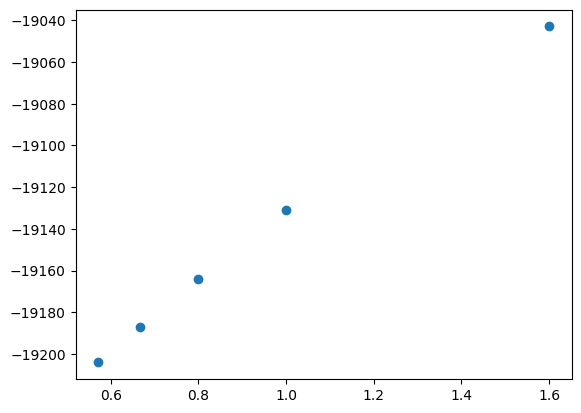

In [30]:
dz = 200 / np.asarray(Nzs)
print(objective.size)
print(dz.size)
plt.scatter(dz, [-19043, -19131, -19164, -19187, -19204])